# Day2+ Section 8 — Fixed-Target Coverage vs Similarity Analysis

This notebook adds a **confound-aware** analysis to Day2+.

The previous pooled geometry analysis showed a counterintuitive negative association between covariance distance and transfer RMSE. However, that result is confounded by source-domain count: larger source sets naturally have broader covariance and often lower RMSE.

Therefore, this notebook reframes the question as an exploratory fixed-target comparison:

> For a given target board, does transfer performance align better with source-target similarity or with source-domain coverage?

Targets are deliberately selected as three contrasting cases:

- **B1**: hard target
- **B2**: relatively typical/central target
- **B5**: drifted/dynamically shifted target

Important limitation: the dataset contains only five boards. All correlations and bootstrap intervals here are exploratory diagnostics, not confirmatory statistical evidence.

In [1]:
from pathlib import Path
import sys
import itertools
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == "notebooks" else Path.cwd().resolve()
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIG_DIR = PROJECT_ROOT / "figures" / "day2plus"
RESULT_DIR = PROJECT_ROOT / "results" / "day2plus"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR:", SRC_DIR)
print("DATA_DIR:", DATA_DIR)
print("FIG_DIR:", FIG_DIR)
print("RESULT_DIR:", RESULT_DIR)

if not SRC_DIR.exists():
    raise FileNotFoundError(f"Missing src directory: {SRC_DIR}")
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Missing raw data directory: {DATA_DIR}")

PROJECT_ROOT: C:\Users\hg\PycharmProjects\mox_calibration_transfer
SRC_DIR: C:\Users\hg\PycharmProjects\mox_calibration_transfer\src
DATA_DIR: C:\Users\hg\PycharmProjects\mox_calibration_transfer\data\raw
FIG_DIR: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2plus
RESULT_DIR: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2plus


In [2]:
from day2plus_transfer_matrix import (
    TARGET_GAS,
    RANDOM_STATE,
    assert_no_label_leakage,
    build_feature_table,
    get_feature_columns,
    evaluate_split,
)

PRIMARY_FEATURE_SET = "physics"
PRIMARY_MODEL = "RandomForest"
FIXED_TARGETS = ["B1", "B2", "B5"]
ALL_BOARDS = ["B1", "B2", "B3", "B4", "B5"]
BOOTSTRAP_N = 3000
rng = np.random.default_rng(RANDOM_STATE)

## 1. Load methane feature table

Feature construction follows the same Day2/Day2+ logic. The leakage check ensures that concentration labels and metadata are not included as model input features.

In [3]:
feature_cache = RESULT_DIR / "day2plus_feature_table_GMe.csv"

if feature_cache.exists():
    df = pd.read_csv(feature_cache)
    print("Loaded cached feature table:", feature_cache)
else:
    df = build_feature_table(DATA_DIR, gas=TARGET_GAS)
    df.to_csv(feature_cache, index=False)
    print("Built and cached feature table:", feature_cache)

feature_cols = get_feature_columns(df, PRIMARY_FEATURE_SET)
leakage_report = assert_no_label_leakage(df)

print("Feature table shape:", df.shape)
print("Boards:", sorted(df["board"].unique()))
print("Feature set:", PRIMARY_FEATURE_SET, "n_features=", len(feature_cols))
print("Leakage check:", leakage_report[PRIMARY_FEATURE_SET])
display(df[["filename", "board", "gas", "concentration_code", "concentration_numeric"]].head())

Loaded cached feature table: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2plus\day2plus_feature_table_GMe.csv
Feature table shape: (160, 126)
Boards: ['B1', 'B2', 'B3', 'B4', 'B5']
Feature set: physics n_features= 71
Leakage check: {'n_features': 71, 'leakage_overlap': [], 'ok': True}


,filename,board,gas,concentration_code,concentration_numeric
0,B1_GMe_F010_R1.txt,B1,GMe,F010,10
1,B1_GMe_F010_R2.txt,B1,GMe,F010,10
2,B1_GMe_F010_R3.txt,B1,GMe,F010,10
3,B1_GMe_F010_R4.txt,B1,GMe,F010,10
4,B1_GMe_F020_R1.txt,B1,GMe,F020,20


## 2. Build or load all source-combination transfer results

For each target board, all valid source combinations are evaluated: 1-source, 2-source, 3-source, and 4-source. The target board is always excluded from the source set.

In [4]:
perf_csv = RESULT_DIR / "fixed_target_transfer_performance.csv"
pred_csv = RESULT_DIR / "fixed_target_transfer_predictions.csv"

if perf_csv.exists():
    transfer_df = pd.read_csv(perf_csv)
    print("Loaded transfer performance:", perf_csv)
else:
    metric_rows = []
    pred_rows = []
    for target in ALL_BOARDS:
        candidate_sources = [b for b in ALL_BOARDS if b != target]
        for k in range(1, len(candidate_sources) + 1):
            for sources in itertools.combinations(candidate_sources, k):
                metrics, preds = evaluate_split(
                    df,
                    source_boards=list(sources),
                    target_board=target,
                    feature_set=PRIMARY_FEATURE_SET,
                    model_name=PRIMARY_MODEL,
                    random_state=RANDOM_STATE,
                )
                metric_rows.append(metrics)
                pred_rows.append(preds)
    transfer_df = pd.DataFrame(metric_rows)
    pred_df = pd.concat(pred_rows, ignore_index=True)
    transfer_df.to_csv(perf_csv, index=False)
    pred_df.to_csv(pred_csv, index=False)
    print("Saved transfer performance:", perf_csv)
    print("Saved predictions:", pred_csv)

transfer_df = transfer_df[(transfer_df["feature_set"] == PRIMARY_FEATURE_SET) & (transfer_df["model"] == PRIMARY_MODEL)].copy()
transfer_df["source_tuple"] = transfer_df["source_boards"].apply(lambda s: tuple(str(s).split("+")))
transfer_df["source_count"] = transfer_df["source_tuple"].apply(len)

print("Transfer rows:", len(transfer_df))
display(transfer_df.head())

Saved transfer performance: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2plus\fixed_target_transfer_performance.csv
Saved predictions: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2plus\fixed_target_transfer_predictions.csv
Transfer rows: 75


,source_boards,n_source_boards,target_board,feature_set,model,n_train,n_test,rmse,mae,r2,includes_B5_source,source_tuple,source_count
0,B2,1,B1,physics,RandomForest,40,40,8.160622,6.738750,0.919278,False,"(B2,)",1
1,B3,1,B1,physics,RandomForest,40,40,12.264505,8.894375,0.817675,False,"(B3,)",1
2,B4,1,B1,physics,RandomForest,20,40,17.059493,12.948750,0.647241,False,"(B4,)",1
3,B5,1,B1,physics,RandomForest,20,40,12.973678,9.587500,0.795980,True,"(B5,)",1
4,B2+B3,2,B1,physics,RandomForest,80,40,10.454833,7.156250,0.867511,False,"(B2, B3)",2


## 3. Exploratory check: RMSE vs source count

This plot checks the major confound directly. If RMSE changes strongly with the number of source boards, pooled geometry correlations must be interpreted cautiously.

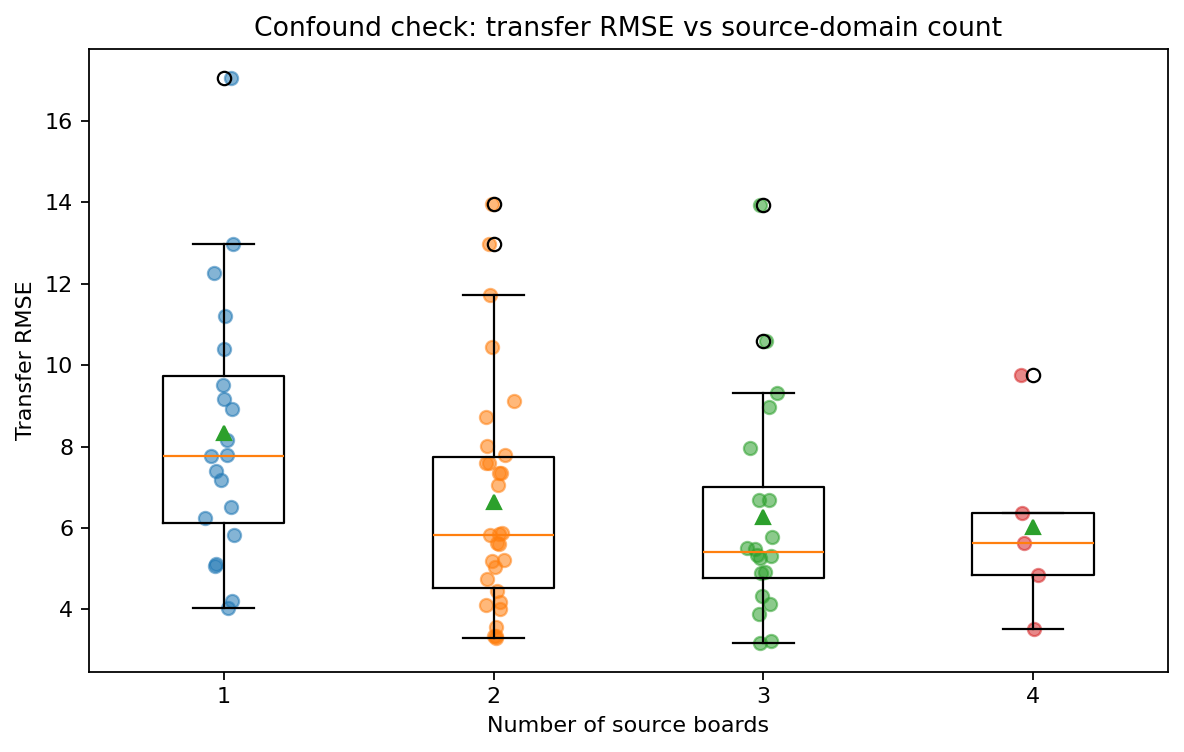

Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2plus\fixed_target_rmse_vs_source_count_boxplot.png


In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=160)
plot_data = [transfer_df.loc[transfer_df["source_count"] == k, "rmse"].values for k in sorted(transfer_df["source_count"].unique())]
ax.boxplot(plot_data, labels=[str(k) for k in sorted(transfer_df["source_count"].unique())], showmeans=True)
for k, vals in zip(sorted(transfer_df["source_count"].unique()), plot_data):
    x = np.full(len(vals), k) + rng.normal(0, 0.035, len(vals))
    ax.scatter(x, vals, alpha=0.55, s=35)
ax.set_xlabel("Number of source boards")
ax.set_ylabel("Transfer RMSE")
ax.set_title("Confound check: transfer RMSE vs source-domain count")
fig.tight_layout()
out = FIG_DIR / "fixed_target_rmse_vs_source_count_boxplot.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print("Saved:", out)

## 4. Geometry metrics for fixed-target source sets

This section computes both competing families of predictors.

**Similarity hypothesis proxies**

- `centroid_dist_full`: Euclidean distance between source and target centroids in globally standardized feature space.
- `centroid_dist_pca5`: centroid distance after global PCA projection to the first five PCs.

**Coverage hypothesis proxies**

- `source_trace`: total source variance.
- `source_intrinsic_dim_95`: number of source PCs needed to explain 95% variance.
- `source_volume_95`: sum of source eigenvalues until 95% cumulative variance is reached.
- `source_top5_volume`: sum of top five source eigenvalues.

The global standardization/PCA is unsupervised and used only for diagnostic geometry, not for model training.

In [6]:
def _clean_X(frame, cols):
    return frame[cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(float).values

X_all = _clean_X(df, feature_cols)
scaler = StandardScaler().fit(X_all)
X_all_scaled = scaler.transform(X_all)

# Global PCA coordinates for comparable centroid-distance diagnostics.
n_pca_global = min(10, X_all_scaled.shape[1], X_all_scaled.shape[0] - 1)
pca_global = PCA(n_components=n_pca_global, random_state=RANDOM_STATE).fit(X_all_scaled)
X_all_pca = pca_global.transform(X_all_scaled)

scaled_df = df[["board", "concentration_numeric", "sample_id"]].copy()
for j in range(X_all_scaled.shape[1]):
    scaled_df[f"z{j}"] = X_all_scaled[:, j]
for j in range(X_all_pca.shape[1]):
    scaled_df[f"PC{j+1}"] = X_all_pca[:, j]

z_cols = [c for c in scaled_df.columns if c.startswith("z")]
pc_cols = [c for c in scaled_df.columns if c.startswith("PC")]


def eigen_coverage_metrics(X):
    """Return source-only PCA/eigenvalue coverage metrics."""
    X = np.asarray(X, dtype=float)
    if X.shape[0] < 3:
        return {
            "source_trace": np.nan,
            "source_intrinsic_dim_95": np.nan,
            "source_volume_95": np.nan,
            "source_top5_volume": np.nan,
            "source_effective_rank": np.nan,
        }
    Xc = X - X.mean(axis=0, keepdims=True)
    cov = np.cov(Xc, rowvar=False)
    eig = np.linalg.eigvalsh(cov)
    eig = np.sort(np.clip(eig, 0, None))[::-1]
    eig = eig[eig > 1e-12]
    if eig.size == 0:
        return {
            "source_trace": 0.0,
            "source_intrinsic_dim_95": 0,
            "source_volume_95": 0.0,
            "source_top5_volume": 0.0,
            "source_effective_rank": 0.0,
        }
    total = float(eig.sum())
    cum = np.cumsum(eig) / total
    k95 = int(np.searchsorted(cum, 0.95) + 1)
    p = eig / total
    effective_rank = float(np.exp(-(p * np.log(p + 1e-12)).sum()))
    return {
        "source_trace": total,
        "source_intrinsic_dim_95": k95,
        "source_volume_95": float(eig[:k95].sum()),
        "source_top5_volume": float(eig[:min(5, len(eig))].sum()),
        "source_effective_rank": effective_rank,
    }


def high_concentration_metrics(source_boards, target_board, threshold=80):
    """Concentration-aware diagnostic for high-concentration response regimes."""
    src_mask = scaled_df["board"].isin(source_boards) & (scaled_df["concentration_numeric"] >= threshold)
    tgt_mask = scaled_df["board"].eq(target_board) & (scaled_df["concentration_numeric"] >= threshold)
    if src_mask.sum() < 3 or tgt_mask.sum() < 3:
        return {
            "high_conc_source_trace": np.nan,
            "high_conc_centroid_dist": np.nan,
        }
    Xs = scaled_df.loc[src_mask, z_cols].values
    Xt = scaled_df.loc[tgt_mask, z_cols].values
    cov_metrics = eigen_coverage_metrics(Xs)
    return {
        "high_conc_source_trace": cov_metrics["source_trace"],
        "high_conc_centroid_dist": float(np.linalg.norm(Xs.mean(axis=0) - Xt.mean(axis=0))),
    }


def geometry_for_split(source_boards, target_board):
    src_mask = scaled_df["board"].isin(source_boards)
    tgt_mask = scaled_df["board"].eq(target_board)
    Xs = scaled_df.loc[src_mask, z_cols].values
    Xt = scaled_df.loc[tgt_mask, z_cols].values
    Xs_pca = scaled_df.loc[src_mask, pc_cols].values
    Xt_pca = scaled_df.loc[tgt_mask, pc_cols].values

    out = eigen_coverage_metrics(Xs)
    out.update({
        "centroid_dist_full": float(np.linalg.norm(Xs.mean(axis=0) - Xt.mean(axis=0))),
        "centroid_dist_pca5": float(np.linalg.norm(Xs_pca[:, :5].mean(axis=0) - Xt_pca[:, :5].mean(axis=0))),
    })
    out.update(high_concentration_metrics(source_boards, target_board, threshold=80))
    return out

rows = []
for _, r in transfer_df.iterrows():
    sources = tuple(r["source_tuple"])
    target = r["target_board"]
    g = geometry_for_split(sources, target)
    rows.append({
        "source_boards": r["source_boards"],
        "source_tuple": sources,
        "target_board": target,
        "source_count": len(sources),
        "rmse": r["rmse"],
        "mae": r["mae"],
        "r2": r["r2"],
        "includes_B5_source": "B5" in sources,
        **g,
    })

geom_df = pd.DataFrame(rows)
geom_csv = RESULT_DIR / "fixed_target_coverage_similarity_metrics.csv"
geom_df.to_csv(geom_csv, index=False)
print("Saved:", geom_csv)
display(geom_df.head())

Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2plus\fixed_target_coverage_similarity_metrics.csv


,source_boards,source_tuple,target_board,source_count,rmse,mae,r2,includes_B5_source,source_trace,source_intrinsic_dim_95,source_volume_95,source_top5_volume,source_effective_rank,centroid_dist_full,centroid_dist_pca5,high_conc_source_trace,high_conc_centroid_dist
0,B2,"(B2,)",B1,1,8.160622,6.738750,0.919278,False,35.965928,4,34.379511,34.910421,3.122723,5.480693,4.704943,19.520061,6.676565
1,B3,"(B3,)",B1,1,12.264505,8.894375,0.817675,False,40.541138,5,39.405466,39.405466,3.540378,6.451881,6.106538,16.863741,7.085007
2,B4,"(B4,)",B1,1,17.059493,12.948750,0.647241,False,27.937686,4,26.896394,27.280930,2.112368,6.687263,5.367863,2.765989,7.662057
3,B5,"(B5,)",B1,1,12.973678,9.587500,0.795980,True,210.347274,4,201.088081,205.992116,3.785921,8.948991,8.571738,241.045607,10.784762
4,B2+B3,"(B2, B3)",B1,2,10.454833,7.156250,0.867511,False,42.361182,6,40.890483,40.021141,4.247291,5.594453,5.190525,23.619031,6.436453


## 5. Correlation with bootstrap confidence intervals

Because each fixed-target subset has at most 15 source combinations, the bootstrap intervals are used only as uncertainty diagnostics. Wide intervals should be expected.

In [7]:
def pearson_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 3 or np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def spearman_corr(x, y):
    return pearson_corr(pd.Series(x).rank().values, pd.Series(y).rank().values)


def bootstrap_corr_ci(x, y, method="pearson", n_boot=BOOTSTRAP_N, seed=RANDOM_STATE):
    data = pd.DataFrame({"x": x, "y": y}).replace([np.inf, -np.inf], np.nan).dropna()
    n = len(data)
    if n < 4 or data["x"].nunique() < 2 or data["y"].nunique() < 2:
        return np.nan, np.nan, np.nan, n
    corr_fn = pearson_corr if method == "pearson" else spearman_corr
    point = corr_fn(data["x"].values, data["y"].values)
    rs = np.random.default_rng(seed)
    boots = []
    arr = data[["x", "y"]].values
    for _ in range(n_boot):
        idx = rs.integers(0, n, n)
        sample = arr[idx]
        if np.nanstd(sample[:, 0]) == 0 or np.nanstd(sample[:, 1]) == 0:
            continue
        boots.append(corr_fn(sample[:, 0], sample[:, 1]))
    if len(boots) < 50:
        return point, np.nan, np.nan, n
    lo, hi = np.nanpercentile(boots, [2.5, 97.5])
    return point, float(lo), float(hi), n

metrics_to_compare = [
    "centroid_dist_full",
    "centroid_dist_pca5",
    "source_trace",
    "source_volume_95",
    "source_intrinsic_dim_95",
    "source_top5_volume",
    "source_effective_rank",
    "high_conc_source_trace",
    "high_conc_centroid_dist",
]

corr_rows = []
for target in FIXED_TARGETS:
    sub = geom_df[geom_df["target_board"] == target].copy()
    for metric in metrics_to_compare:
        for method in ["pearson", "spearman"]:
            point, lo, hi, n = bootstrap_corr_ci(sub[metric], sub["rmse"], method=method)
            corr_rows.append({
                "target_board": target,
                "metric": metric,
                "method": method,
                "n": n,
                "corr": point,
                "ci95_low": lo,
                "ci95_high": hi,
                "abs_corr": abs(point) if pd.notna(point) else np.nan,
            })

corr_df = pd.DataFrame(corr_rows)
corr_csv = RESULT_DIR / "fixed_target_bootstrap_correlations.csv"
corr_df.to_csv(corr_csv, index=False)
print("Saved:", corr_csv)

display(corr_df.sort_values(["target_board", "method", "abs_corr"], ascending=[True, True, False]))

Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2plus\fixed_target_bootstrap_correlations.csv


,target_board,metric,method,n,corr,ci95_low,ci95_high,abs_corr
0,B1,centroid_dist_full,pearson,15,0.522948,0.359869,0.849323,0.522948
16,B1,high_conc_centroid_dist,pearson,15,0.400303,0.242961,0.807687,0.400303
2,B1,centroid_dist_pca5,pearson,15,0.393407,0.056285,0.771384,0.393407
12,B1,source_effective_rank,pearson,15,-0.359055,-0.791604,0.268615,0.359055
8,B1,source_intrinsic_dim_95,pearson,15,-0.302694,-0.741578,0.241785,0.302694
10,B1,source_top5_volume,pearson,15,0.074288,-0.477249,0.566335,0.074288
4,B1,source_trace,pearson,15,0.049425,-0.497187,0.561866,0.049425
6,B1,source_volume_95,pearson,15,0.048317,-0.496511,0.567355,0.048317
14,B1,high_conc_source_trace,pearson,15,0.019118,-0.535094,0.539350,0.019118
1,B1,centroid_dist_full,spearman,15,0.642857,0.267702,0.795550,0.642857


## 6. Fixed-target plots: similarity vs coverage

Each target is shown separately. This avoids mixing target difficulty with source composition.

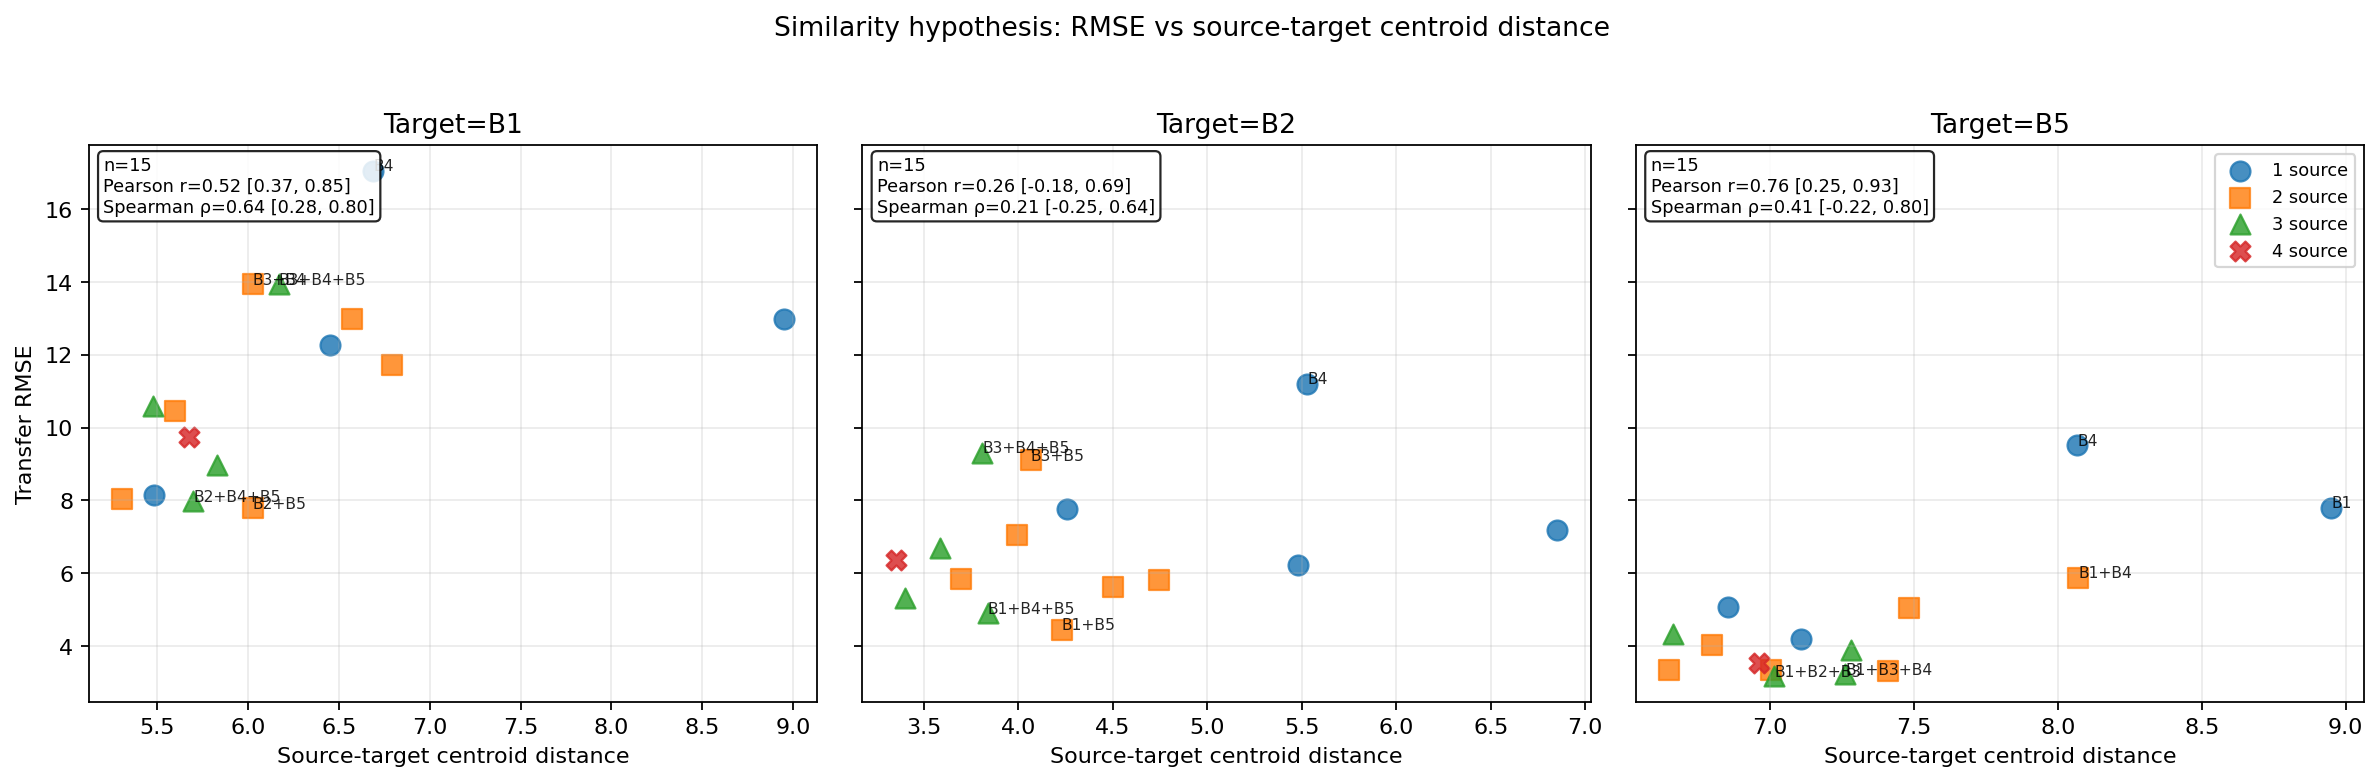

Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2plus\fixed_target_rmse_vs_centroid_distance.png


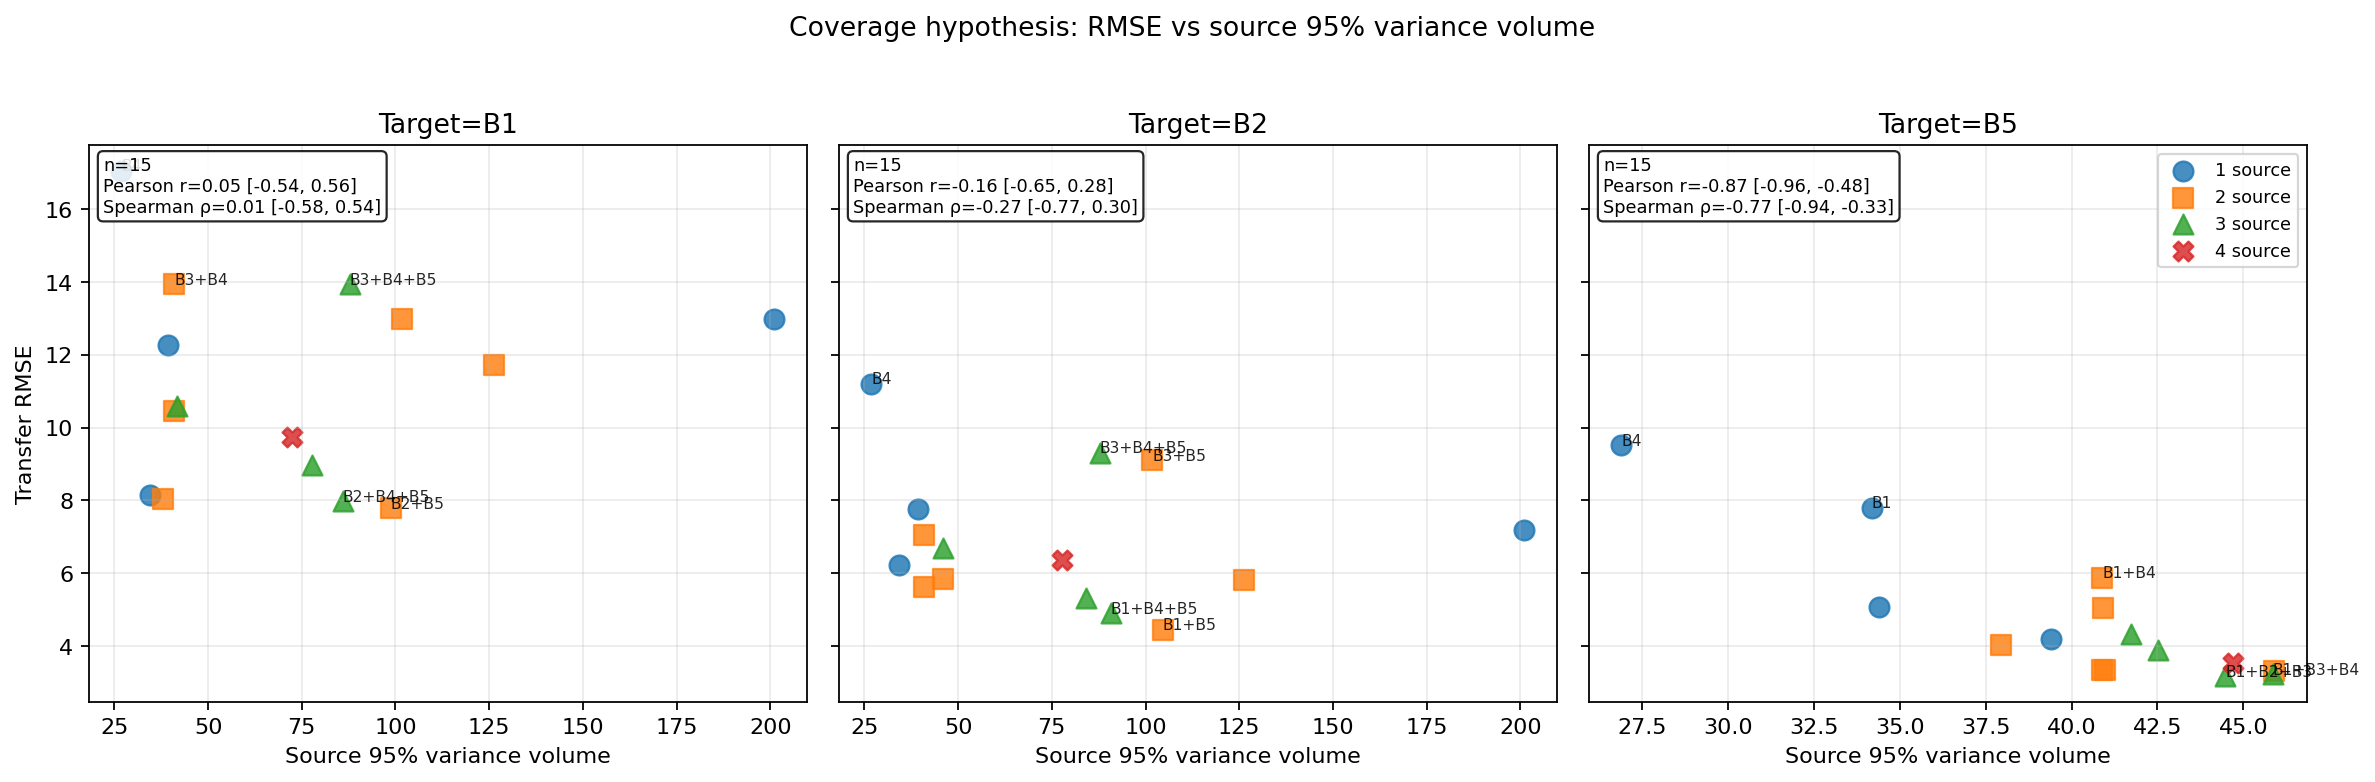

Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2plus\fixed_target_rmse_vs_source_volume95.png


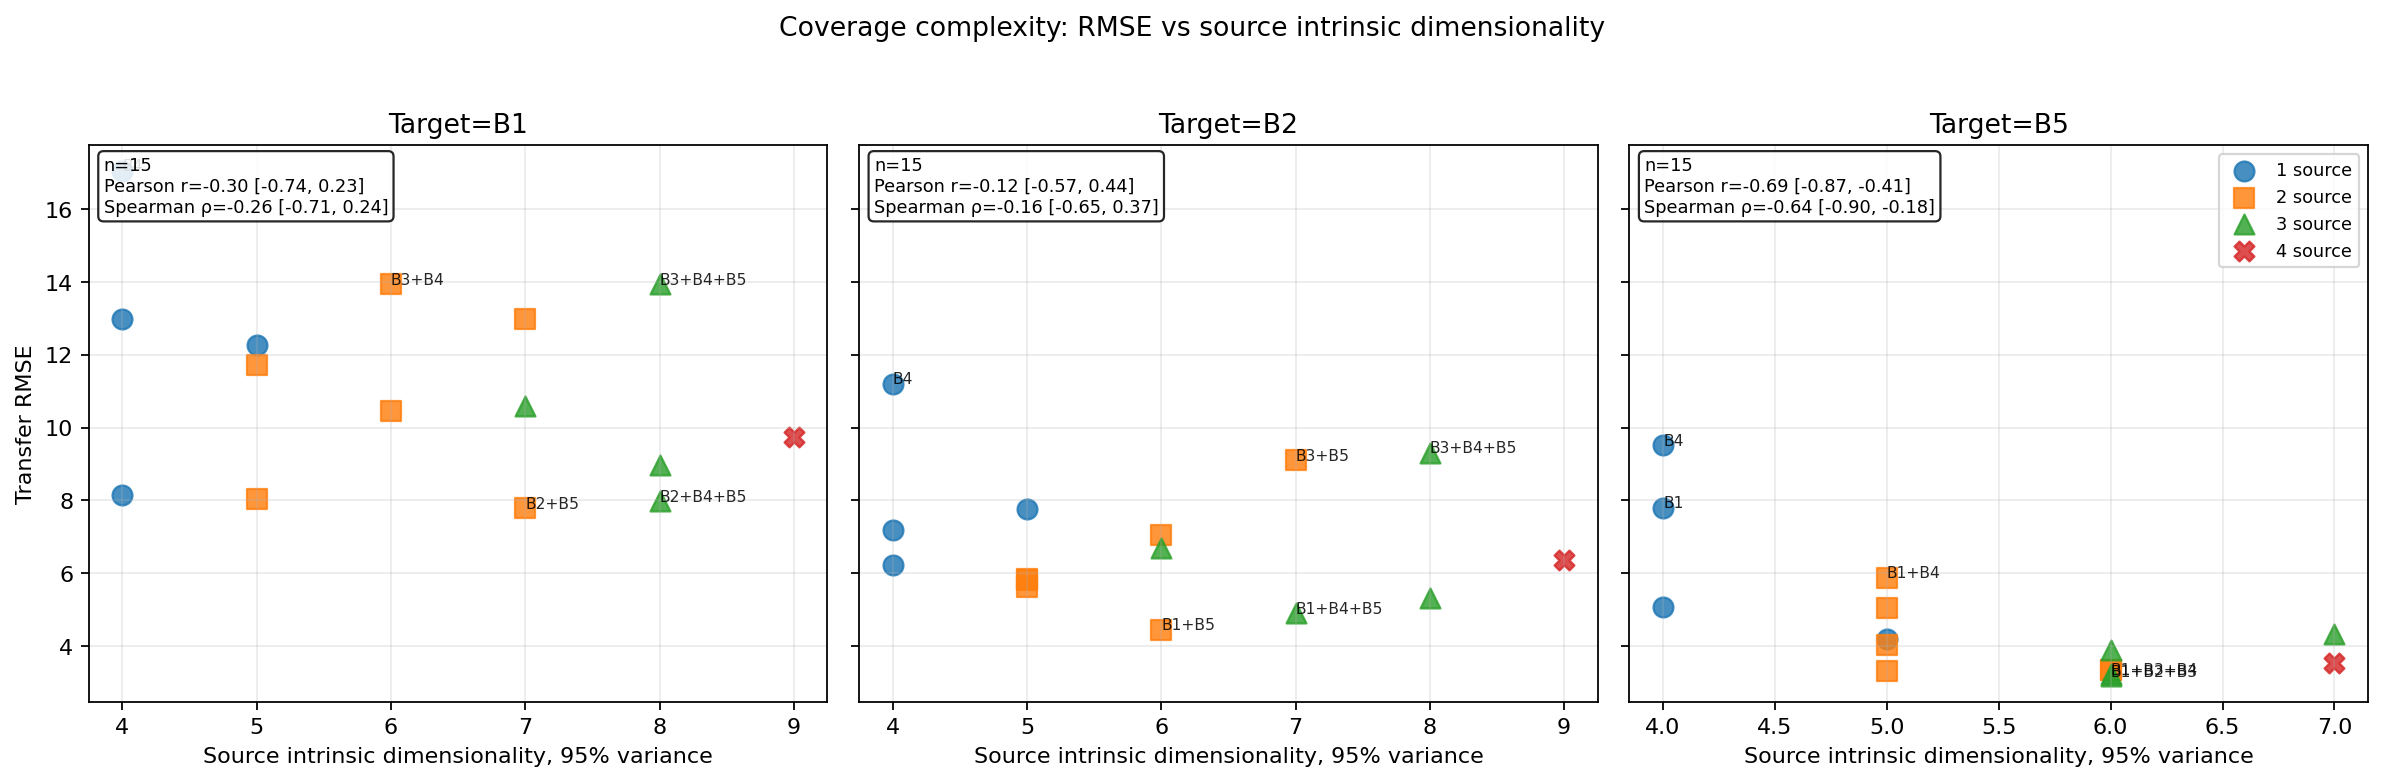

Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2plus\fixed_target_rmse_vs_intrinsic_dim95.png


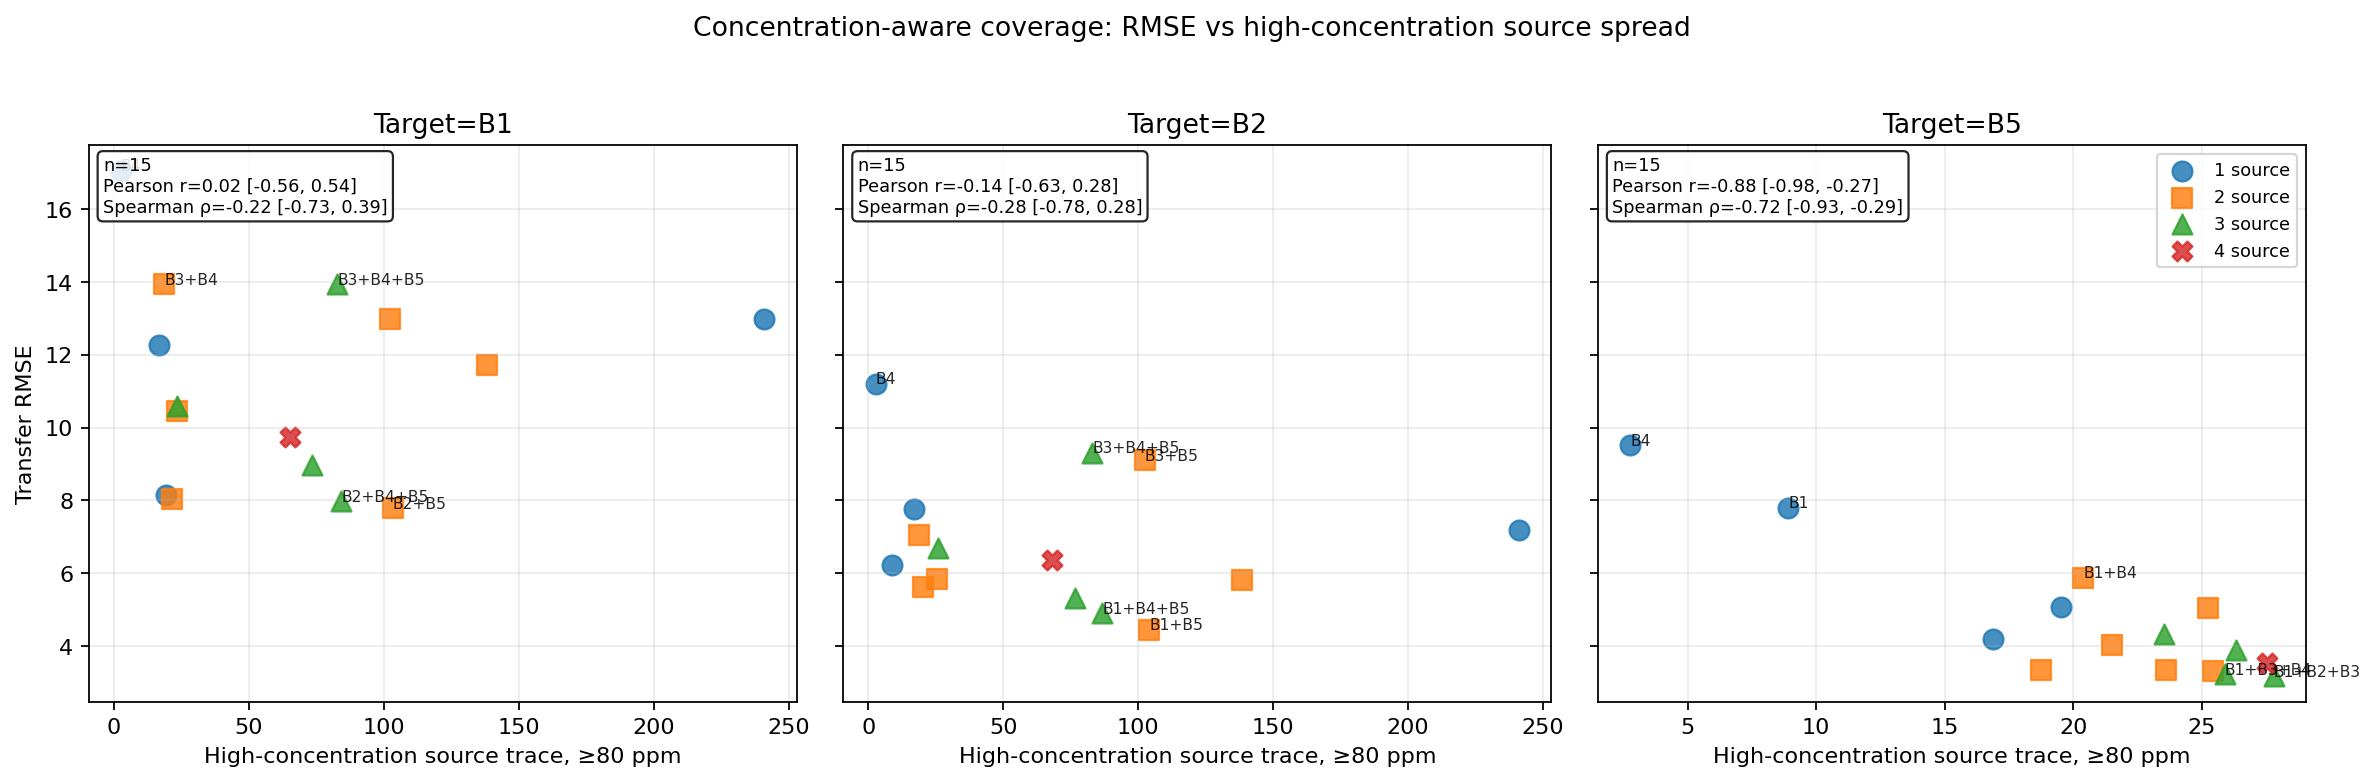

Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2plus\fixed_target_rmse_vs_high_conc_source_trace.png


In [8]:
def add_corr_text(ax, x, y):
    p, plo, phi, n = bootstrap_corr_ci(x, y, method="pearson", n_boot=1000)
    s, slo, shi, _ = bootstrap_corr_ci(x, y, method="spearman", n_boot=1000)
    ax.text(
        0.02, 0.98,
        f"n={n}\nPearson r={p:.2f} [{plo:.2f}, {phi:.2f}]\nSpearman ρ={s:.2f} [{slo:.2f}, {shi:.2f}]",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=8,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    )


def fixed_target_scatter(x_col, ylabel, filename, title_prefix=""):
    fig, axes = plt.subplots(1, len(FIXED_TARGETS), figsize=(15, 4.7), dpi=160, sharey=True)
    for ax, target in zip(axes, FIXED_TARGETS):
        sub = geom_df[geom_df["target_board"] == target].copy()
        for k, marker in [(1, "o"), (2, "s"), (3, "^"), (4, "X")]:
            part = sub[sub["source_count"] == k]
            ax.scatter(part[x_col], part["rmse"], s=80, marker=marker, alpha=0.82, label=f"{k} source")
        for _, r in sub.iterrows():
            if r["rmse"] in sub["rmse"].nlargest(3).values or r["rmse"] in sub["rmse"].nsmallest(2).values:
                ax.annotate(r["source_boards"], (r[x_col], r["rmse"]), fontsize=7, alpha=0.85)
        add_corr_text(ax, sub[x_col], sub["rmse"])
        ax.set_title(f"Target={target}")
        ax.set_xlabel(ylabel)
        ax.grid(True, alpha=0.25)
    axes[0].set_ylabel("Transfer RMSE")
    axes[-1].legend(loc="best", fontsize=8)
    fig.suptitle(title_prefix or f"Fixed-target RMSE vs {x_col}", y=1.03)
    fig.tight_layout()
    out = FIG_DIR / filename
    fig.savefig(out, bbox_inches="tight")
    plt.show()
    print("Saved:", out)

fixed_target_scatter(
    "centroid_dist_full",
    "Source-target centroid distance",
    "fixed_target_rmse_vs_centroid_distance.png",
    "Similarity hypothesis: RMSE vs source-target centroid distance",
)

fixed_target_scatter(
    "source_volume_95",
    "Source 95% variance volume",
    "fixed_target_rmse_vs_source_volume95.png",
    "Coverage hypothesis: RMSE vs source 95% variance volume",
)

fixed_target_scatter(
    "source_intrinsic_dim_95",
    "Source intrinsic dimensionality, 95% variance",
    "fixed_target_rmse_vs_intrinsic_dim95.png",
    "Coverage complexity: RMSE vs source intrinsic dimensionality",
)

fixed_target_scatter(
    "high_conc_source_trace",
    "High-concentration source trace, ≥80 ppm",
    "fixed_target_rmse_vs_high_conc_source_trace.png",
    "Concentration-aware coverage: RMSE vs high-concentration source spread",
)

## 7. Side-by-side predictive comparison

This table compares the absolute correlation magnitude of similarity and coverage metrics for each fixed target. Because the bootstrap intervals are likely wide, the result should be interpreted as a ranking of exploratory evidence rather than a formal model-selection result.

Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2plus\fixed_target_metric_predictive_ranking.csv


,target_board,metric,method,n,corr,ci95_low,ci95_high,abs_corr
0,B1,centroid_dist_full,pearson,15,0.522948,0.359869,0.849323,0.522948
16,B1,high_conc_centroid_dist,pearson,15,0.400303,0.242961,0.807687,0.400303
2,B1,centroid_dist_pca5,pearson,15,0.393407,0.056285,0.771384,0.393407
12,B1,source_effective_rank,pearson,15,-0.359055,-0.791604,0.268615,0.359055
8,B1,source_intrinsic_dim_95,pearson,15,-0.302694,-0.741578,0.241785,0.302694
10,B1,source_top5_volume,pearson,15,0.074288,-0.477249,0.566335,0.074288
4,B1,source_trace,pearson,15,0.049425,-0.497187,0.561866,0.049425
6,B1,source_volume_95,pearson,15,0.048317,-0.496511,0.567355,0.048317
14,B1,high_conc_source_trace,pearson,15,0.019118,-0.535094,0.539350,0.019118
30,B2,source_effective_rank,pearson,15,-0.305650,-0.770935,0.348471,0.305650


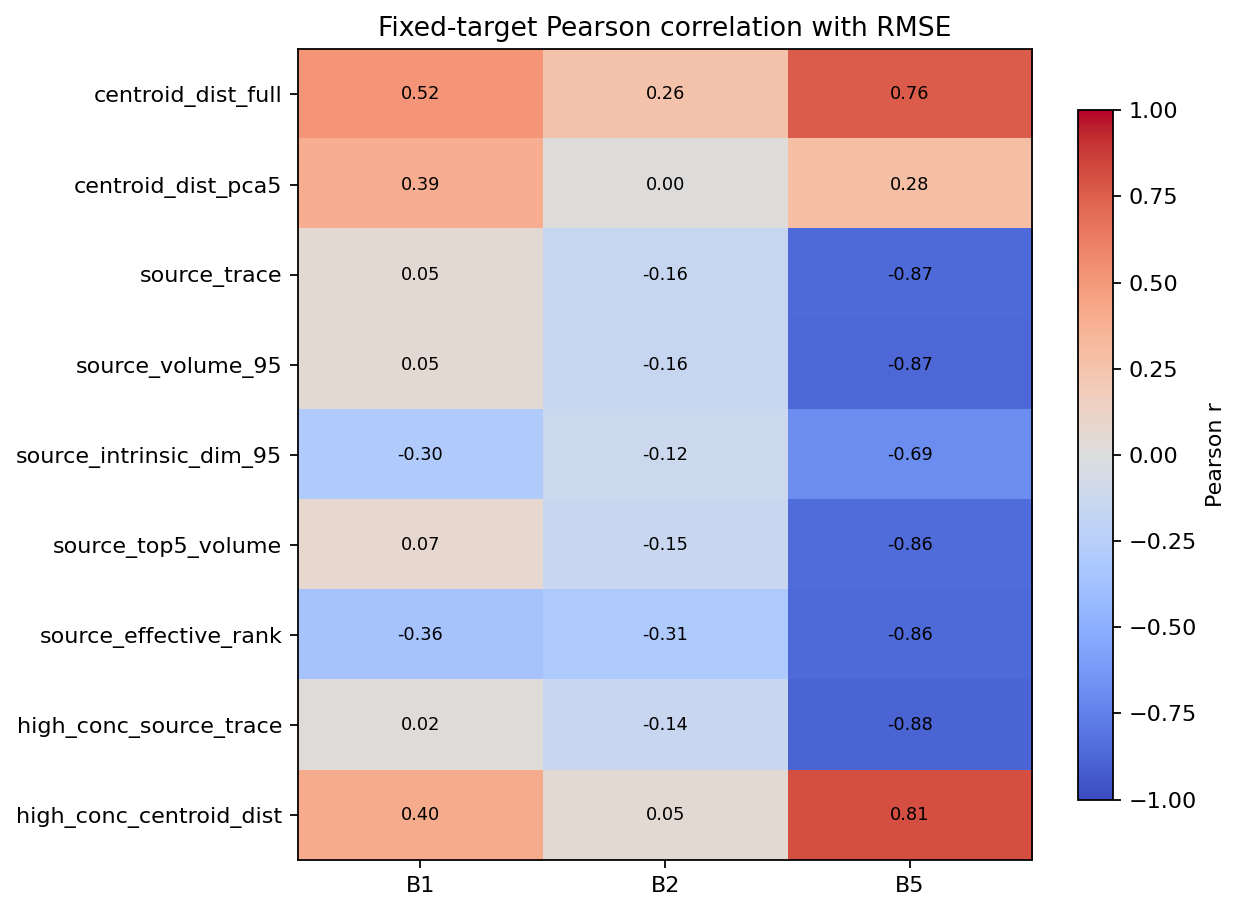

Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2plus\fixed_target_metric_correlation_heatmap.png


In [9]:
pearson_summary = corr_df[corr_df["method"] == "pearson"].copy()
ranked = pearson_summary.sort_values(["target_board", "abs_corr"], ascending=[True, False])
ranked_csv = RESULT_DIR / "fixed_target_metric_predictive_ranking.csv"
ranked.to_csv(ranked_csv, index=False)
print("Saved:", ranked_csv)
display(ranked)

# Compact heatmap-like view of Pearson correlations.
pivot = pearson_summary.pivot(index="metric", columns="target_board", values="corr").loc[metrics_to_compare, FIXED_TARGETS]
fig, ax = plt.subplots(figsize=(7.8, 5.8), dpi=160)
im = ax.imshow(pivot.values, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_xticklabels(pivot.columns)
ax.set_yticklabels(pivot.index)
ax.set_title("Fixed-target Pearson correlation with RMSE")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.85, label="Pearson r")
fig.tight_layout()
out = FIG_DIR / "fixed_target_metric_correlation_heatmap.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print("Saved:", out)

## 8. Concentration-dependent residual check

If coverage metrics remain weak or inconsistent, this is not a failed analysis. It may indicate that transferability is governed by concentration-dependent nonlinear response regimes rather than global geometry alone.

This section summarizes absolute error at low, mid, and high methane concentrations for the fixed targets.

Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2plus\fixed_target_concentration_regime_errors.csv


,target_board,source_boards,conc_regime,mean_abs_error,rmse,n
0,B1,B2,low ≤30,3.337500,4.034099,12
1,B1,B2,mid 40–70,7.312500,8.107944,16
2,B1,B2,high ≥80,9.375000,10.865551,12
3,B1,B2+B3,low ≤30,3.304167,5.242882,12
4,B1,B2+B3,mid 40–70,6.828125,8.662419,16


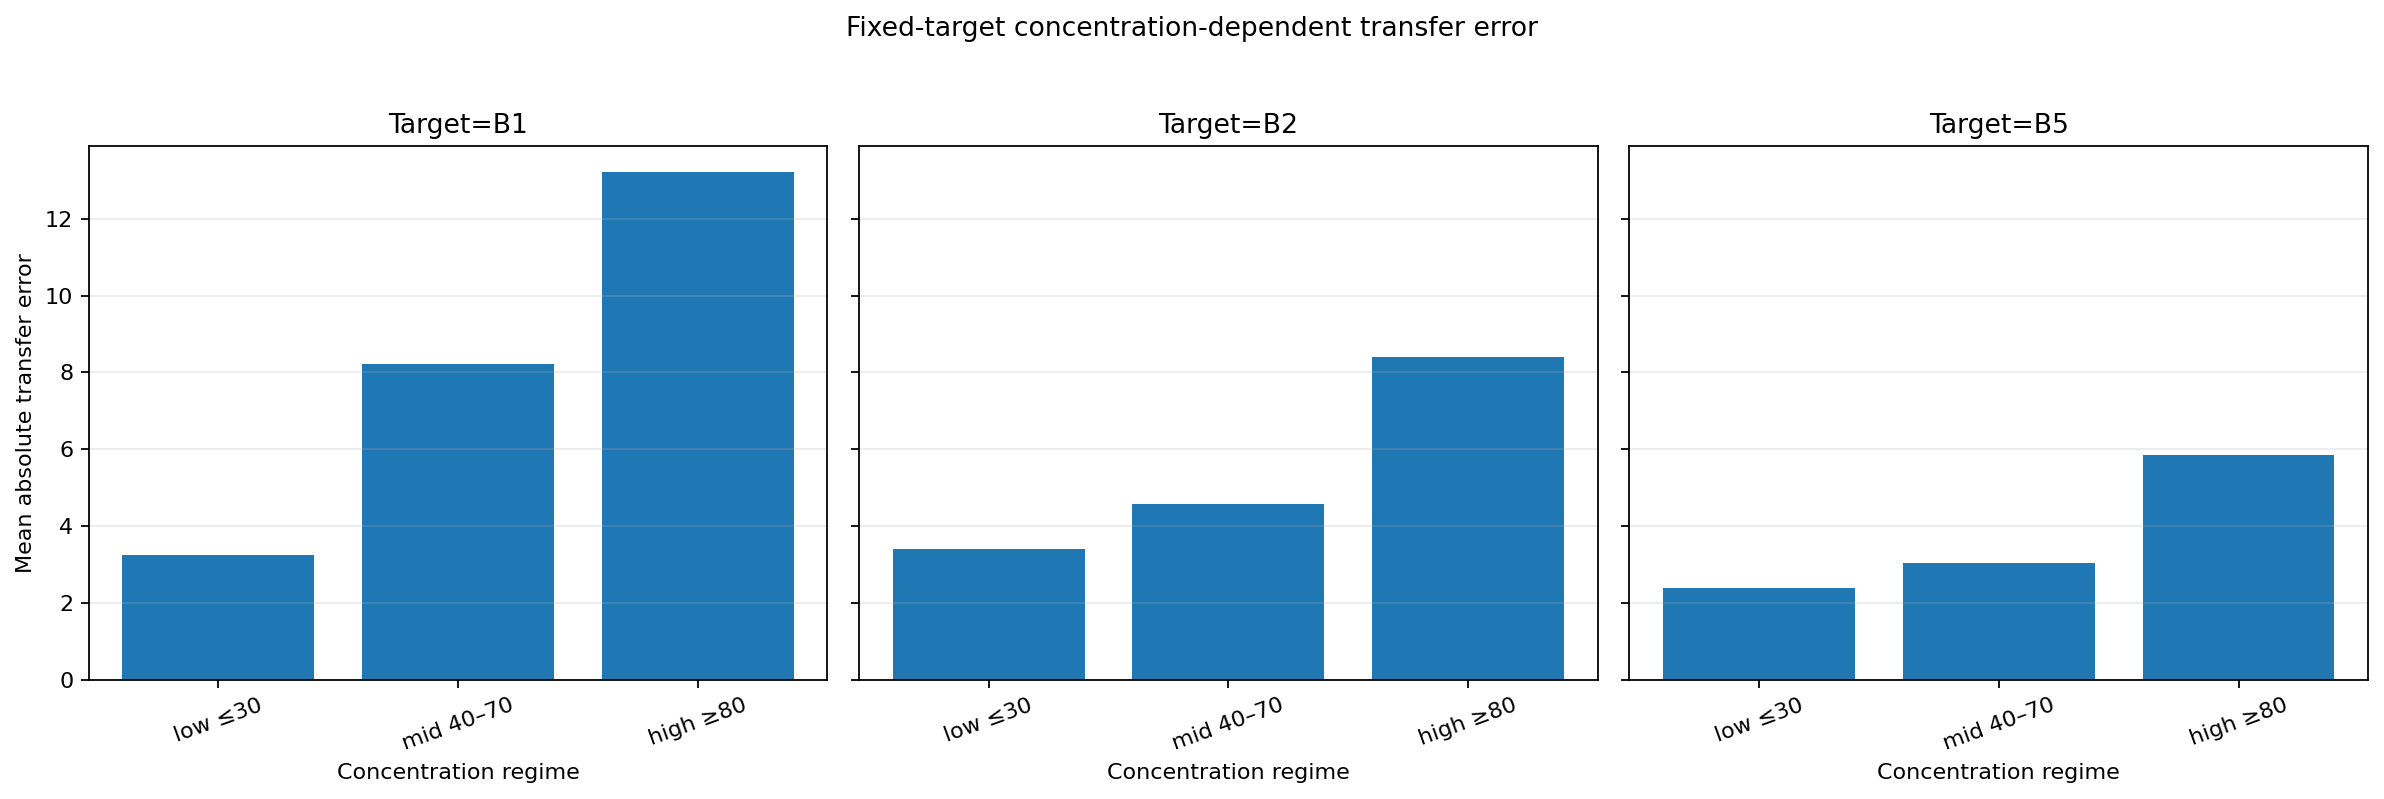

Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2plus\fixed_target_concentration_regime_errors.png


In [10]:
if pred_csv.exists():
    pred_df = pd.read_csv(pred_csv)
else:
    raise FileNotFoundError(f"Missing prediction file: {pred_csv}; rerun Section 2.")

pred_fixed = pred_df[(pred_df["target_board"].isin(FIXED_TARGETS)) &
                     (pred_df["feature_set"] == PRIMARY_FEATURE_SET) &
                     (pred_df["model"] == PRIMARY_MODEL)].copy()

bins = [0, 30, 70, np.inf]
labels = ["low ≤30", "mid 40–70", "high ≥80"]
pred_fixed["conc_regime"] = pd.cut(pred_fixed["concentration_numeric"], bins=bins, labels=labels, include_lowest=True)
regime_summary = (pred_fixed.groupby(["target_board", "source_boards", "conc_regime"], as_index=False)
                  .agg(mean_abs_error=("abs_error", "mean"),
                       rmse=("abs_error", lambda x: math.sqrt(np.mean(np.square(x)))),
                       n=("abs_error", "size")))
regime_csv = RESULT_DIR / "fixed_target_concentration_regime_errors.csv"
regime_summary.to_csv(regime_csv, index=False)
print("Saved:", regime_csv)
display(regime_summary.head())

fig, axes = plt.subplots(1, len(FIXED_TARGETS), figsize=(15, 4.8), dpi=160, sharey=True)
for ax, target in zip(axes, FIXED_TARGETS):
    sub = regime_summary[regime_summary["target_board"] == target]
    # average over source sets for a clean target-level regime view
    avg = sub.groupby("conc_regime", as_index=False)["mean_abs_error"].mean()
    ax.bar(avg["conc_regime"].astype(str), avg["mean_abs_error"])
    ax.set_title(f"Target={target}")
    ax.set_xlabel("Concentration regime")
    ax.tick_params(axis="x", rotation=20)
    ax.grid(True, axis="y", alpha=0.25)
axes[0].set_ylabel("Mean absolute transfer error")
fig.suptitle("Fixed-target concentration-dependent transfer error", y=1.03)
fig.tight_layout()
out = FIG_DIR / "fixed_target_concentration_regime_errors.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print("Saved:", out)

## 9. Interpretation guide

Use the results conservatively.

Possible outcomes:

1. **Coverage metrics outperform centroid distance across B1, B2, and B5**  
   This supports the source-coverage hypothesis: transferable robustness depends more on source manifold support than on simple source-target similarity.

2. **Centroid distance outperforms coverage metrics**  
   This supports a simpler similarity hypothesis: source boards close to the target are better transfer sources.

3. **Both metric families are weak or target-dependent**  
   This is scientifically important, not a failure. It indicates that global geometry is insufficient and that transfer failure likely depends on concentration-specific nonlinear MOx response regimes, especially high-concentration saturation/recovery behavior.

Suggested wording for the notebook/report:

> Given the limited number of independent boards (N=5), the fixed-target analysis is treated as exploratory. The goal is not to prove a universal source-selection rule, but to separate two plausible explanations for transfer behavior: source-target similarity and source-domain coverage. Where both explanations are weak, the result points toward concentration-dependent sensor physics that is not fully captured by global geometry metrics.